# Validation du Module IA — MCDM Academic

**Objectif** : Valider la pertinence et la robustesse des modèles de classification avant leur intégration définitive dans l'application.

**Pipeline** :
1. Chargement & aperçu des données
2. Analyse exploratoire (EDA)
3. Prétraitement & encodage
4. Entraînement de 5 modèles (RF, GB, DT, LR, SVM)
5. Évaluation et comparaison (F1-macro, accuracy, matrice de confusion)
6. Analyse SHAP — importance et explicabilité
7. Courbes d'apprentissage
8. Conclusions

---
**Données** : `version_2/data/input/candidats_mcdm.csv`  
**Cible** : colonne `Tier` (Faible / Moyen / Bon / Excellent)

## 0. Imports & configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, learning_curve
)
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    accuracy_score, ConfusionMatrixDisplay
)

# Style global
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F9FC',
    'axes.edgecolor':   '#DDE2EA',
    'axes.grid':        True,
    'grid.color':       '#DDE2EA',
    'grid.linewidth':   0.7,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
})
PALETTE = ['#C5241C', '#B35A00', '#0A7C42', '#1B3A6B']  # Faible / Moyen / Bon / Excellent
TIER_ORDER = ['Faible', 'Moyen', 'Bon', 'Excellent']

SEED = 42
DATA_PATH = '../data/input/candidats_mcdm.csv'

print('Imports OK')

Imports OK


---
## 1. Chargement & aperçu général

In [2]:
df_raw = pd.read_csv(DATA_PATH)

print(f"Dimensions  : {df_raw.shape[0]} candidats × {df_raw.shape[1]} colonnes")
print(f"Colonnes    : {df_raw.columns.tolist()}")
print()
df_raw.head()

Dimensions  : 815 candidats × 10 colonnes
Colonnes    : ['ID', 'Diplome', 'Diplome_norm', 'Moyenne', 'Moyenne_finale', 'Niveau_Math', 'Alternance', 'Licence_EDN', 'Classement', 'Tier']



,ID,Diplome,Diplome_norm,Moyenne,Moyenne_finale,Niveau_Math,Alternance,Licence_EDN,Classement,Tier
0,1,Licence math info,Licence informatique/mathematique,10.883333,10.883333,sup_12,0.0,NaN,422.0,Faible
1,2,Licence info,Licence informatique,13.000000,13.000000,sup_12,0.0,0.0,64.0,Bon
2,3,licence autre,licence autre,10.240000,10.240000,NaN,0.0,NaN,422.0,Faible
3,4,BUT info,BUT informatique,9.940000,9.940000,inf_12,0.0,0.0,422.0,Faible
4,5,licence info,Licence informatique,10.597000,10.597000,inf_12,0.0,0.0,422.0,Faible


In [3]:
print("=== Types & valeurs manquantes ===")
info = pd.DataFrame({
    'type'    : df_raw.dtypes,
    'manquants': df_raw.isnull().sum(),
    '%'       : (df_raw.isnull().mean() * 100).round(1),
    'uniques' : df_raw.nunique(),
})
info

=== Types & valeurs manquantes ===


,type,manquants,%,uniques
ID,int64,0,0.0,815
Diplome,str,0,0.0,165
Diplome_norm,str,0,0.0,110
Moyenne,float64,29,3.6,512
Moyenne_finale,float64,13,1.6,524
Niveau_Math,str,104,12.8,2
Alternance,float64,23,2.8,3
Licence_EDN,float64,311,38.2,2
Classement,float64,0,0.0,411
Tier,str,13,1.6,4


In [4]:
print("=== Statistiques descriptives (colonnes numériques) ===")
df_raw.describe().round(3)

=== Statistiques descriptives (colonnes numériques) ===


,ID,Moyenne,Moyenne_finale,Alternance,Licence_EDN,Classement
count,815.000,786.000,802.000,792.000,504.000,815.000
mean,408.000,12.138,12.106,0.220,0.036,316.020
std,235.415,1.427,2.385,0.482,0.186,136.893
min,1.000,7.906,0.000,0.000,0.000,1.000
25%,204.500,11.036,11.019,0.000,0.000,214.500
50%,408.000,12.000,12.142,0.000,0.000,419.000
75%,611.500,13.010,13.351,0.000,0.000,422.000
max,815.000,17.420,17.980,2.000,1.000,422.000


---
## 2. Analyse exploratoire (EDA)

### 2.1 Distribution de la variable cible

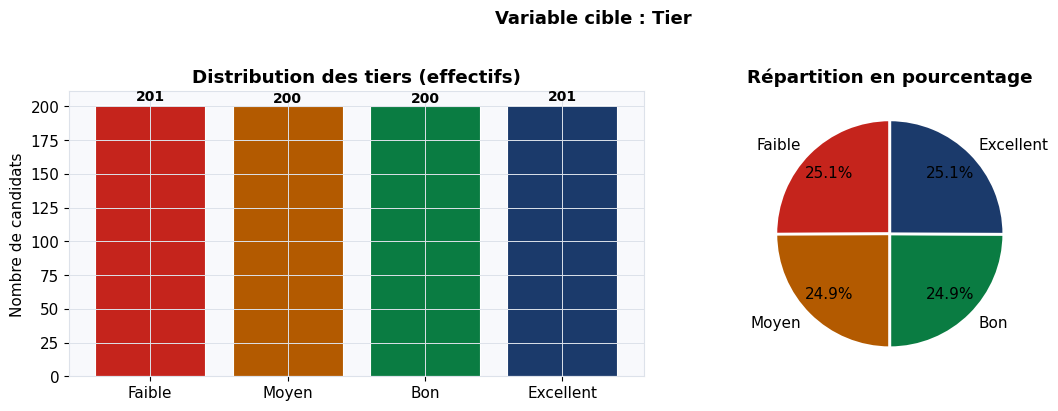


Conclusion : Dataset équilibré — std = 0.6


In [5]:
tier_counts = df_raw['Tier'].value_counts().reindex(TIER_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(TIER_ORDER, tier_counts.values, color=PALETTE, edgecolor='white', linewidth=0.8)
axes[0].set_title('Distribution des tiers (effectifs)', fontweight='bold')
axes[0].set_ylabel('Nombre de candidats')
for i, v in enumerate(tier_counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontsize=10, fontweight='600')

# Pie chart
axes[1].pie(
    tier_counts.values, labels=TIER_ORDER,
    colors=PALETTE, autopct='%1.1f%%',
    startangle=90, pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Répartition en pourcentage', fontweight='bold')

plt.suptitle('Variable cible : Tier', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nConclusion : {'Dataset équilibré' if tier_counts.std() < 10 else 'Déséquilibre à noter'} — std = {tier_counts.std():.1f}")

### 2.2 Distribution des features numériques

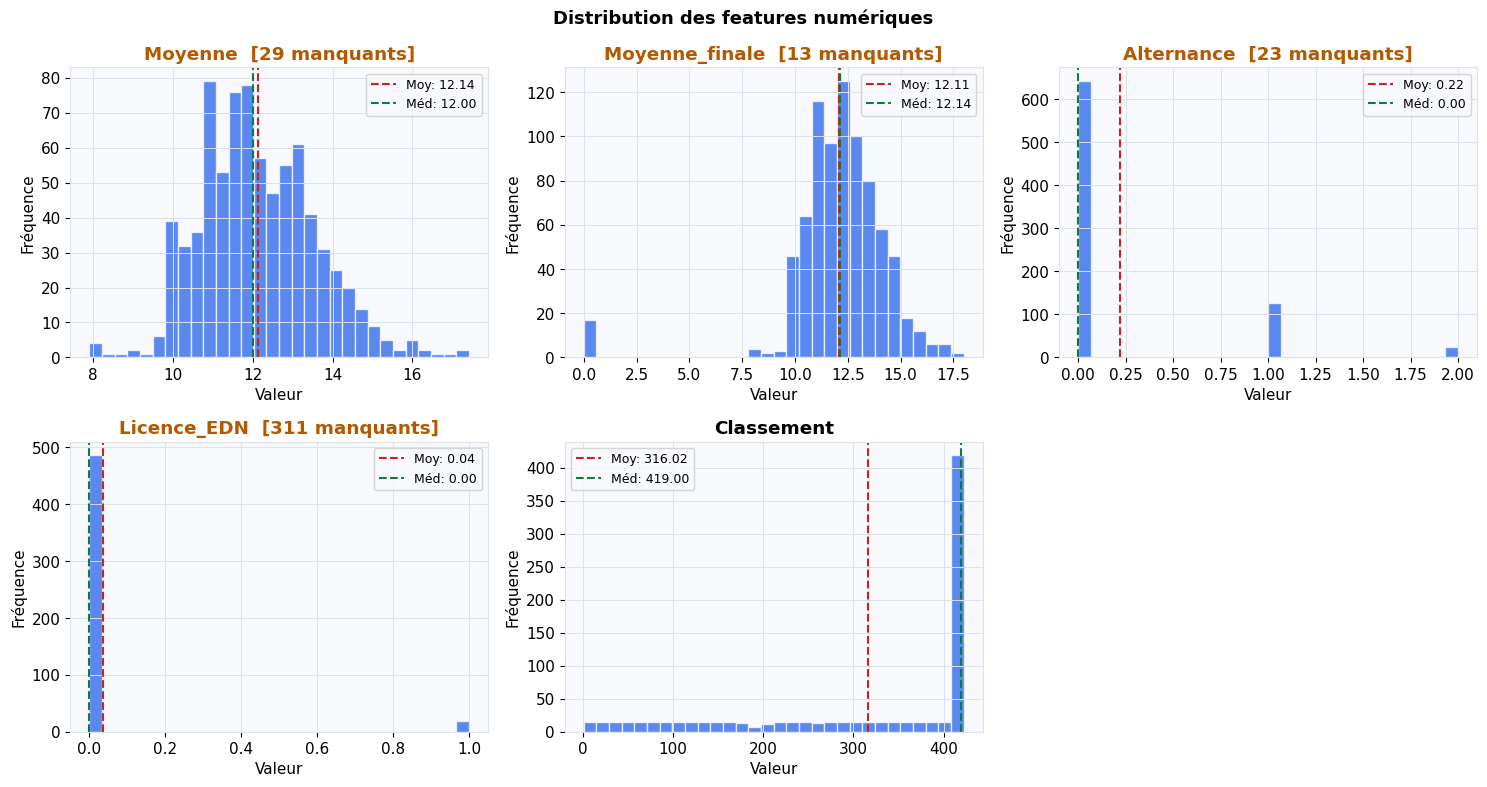

In [6]:
num_cols = ['Moyenne', 'Moyenne_finale', 'Alternance', 'Licence_EDN', 'Classement']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    data = df_raw[col].dropna()
    ax.hist(data, bins=30, color='#2563EB', alpha=0.75, edgecolor='white')
    ax.axvline(data.mean(), color='#C5241C', linestyle='--', linewidth=1.5, label=f'Moy: {data.mean():.2f}')
    ax.axvline(data.median(), color='#0A7C42', linestyle='--', linewidth=1.5, label=f'Méd: {data.median():.2f}')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Valeur')
    ax.set_ylabel('Fréquence')
    ax.legend(fontsize=9)
    n_miss = df_raw[col].isnull().sum()
    if n_miss > 0:
        ax.set_title(f'{col}  [{n_miss} manquants]', fontweight='bold', color='#B35A00')

axes[-1].set_visible(False)
plt.suptitle('Distribution des features numériques', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.3 Features numériques par tier

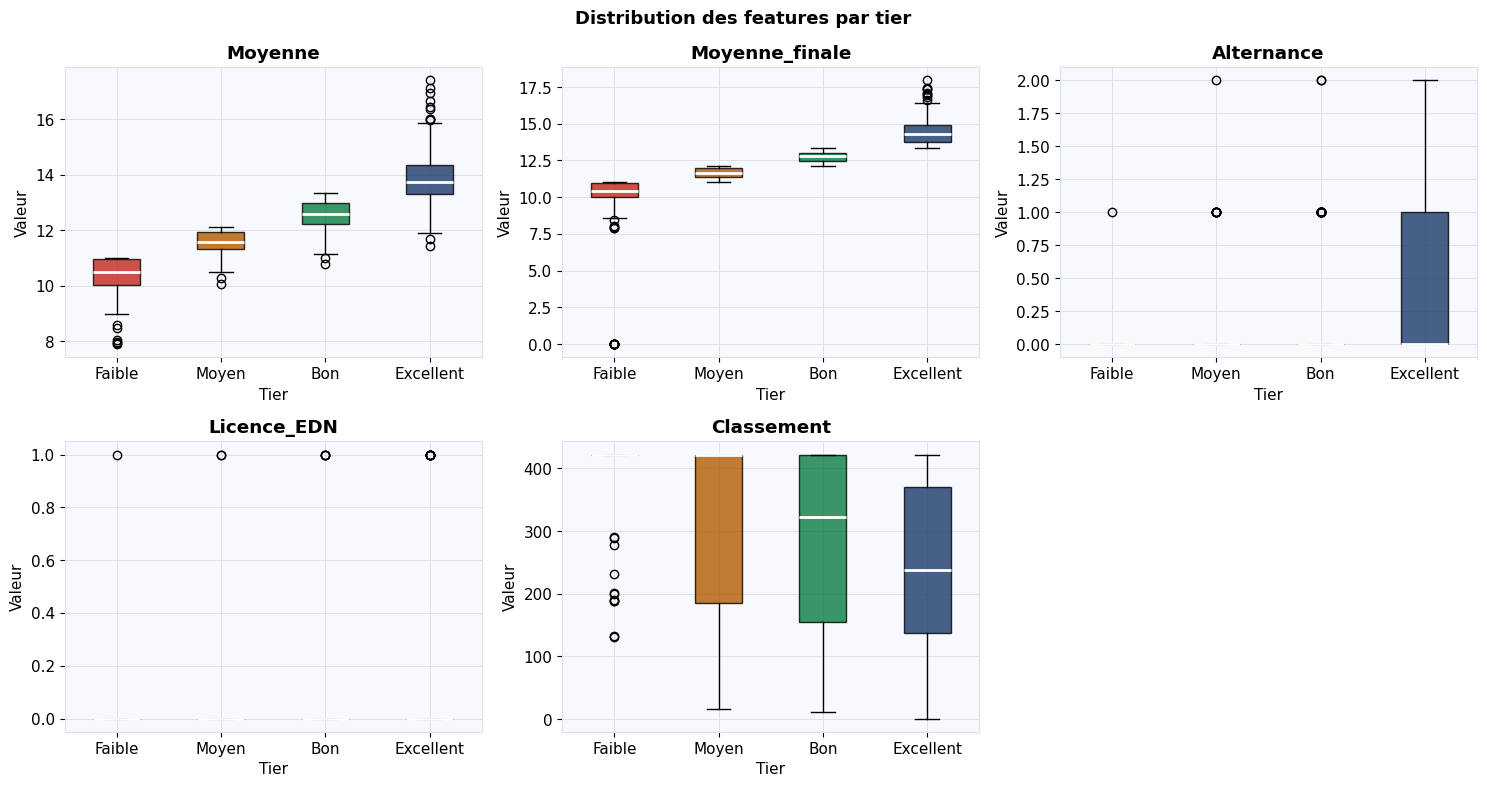

In [7]:
# Boxplots : chaque feature numérique selon le tier
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    data_by_tier = [df_raw[df_raw['Tier'] == t][col].dropna().values for t in TIER_ORDER]
    bp = ax.boxplot(
        data_by_tier, labels=TIER_ORDER,
        patch_artist=True,
        medianprops={'color': 'white', 'linewidth': 2}
    )
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Tier')
    ax.set_ylabel('Valeur')

axes[-1].set_visible(False)
plt.suptitle('Distribution des features par tier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.4 Variables catégorielles

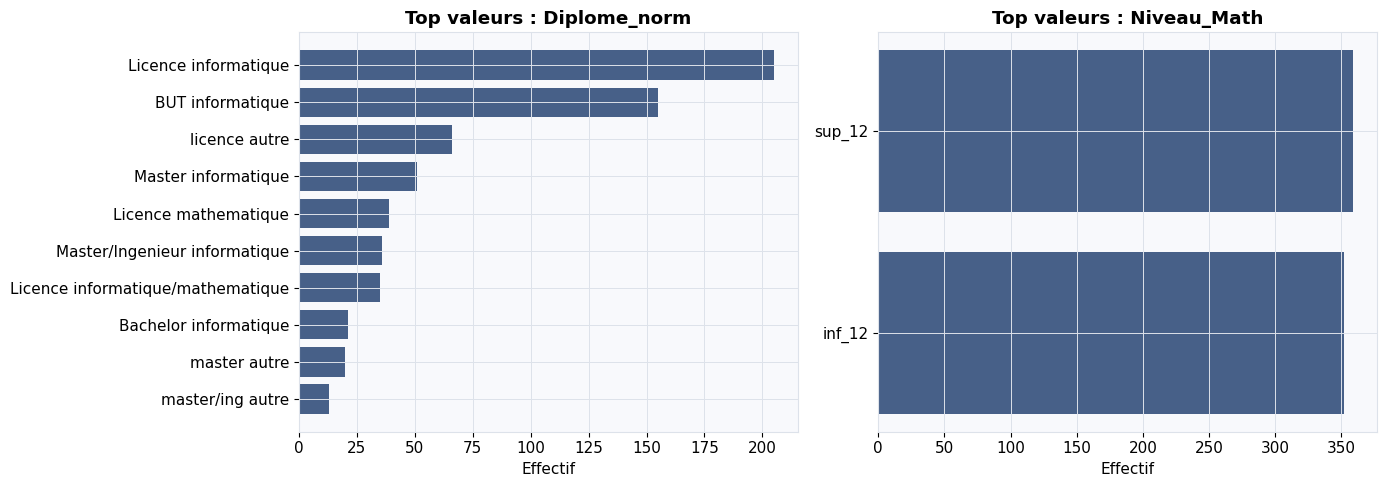

In [8]:
cat_cols = ['Diplome_norm', 'Niveau_Math']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, cat_cols):
    counts = df_raw[col].value_counts().head(10)
    ax.barh(counts.index, counts.values, color='#1B3A6B', alpha=0.8)
    ax.set_title(f'Top valeurs : {col}', fontweight='bold')
    ax.set_xlabel('Effectif')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

### 2.5 Carte de corrélation

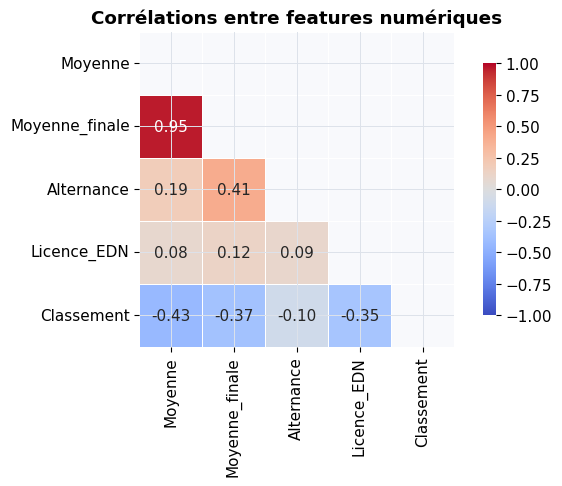

Corrélations fortes (|r| >= 0.70) :
  Moyenne ↔ Moyenne_finale : 0.953


In [9]:
corr = df_raw[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Corrélations entre features numériques', fontweight='bold')
plt.tight_layout()
plt.show()

# Corrélations fortes
high = []
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        r = corr.iloc[i, j]
        if abs(r) >= 0.70:
            high.append((corr.index[i], corr.columns[j], round(r, 3)))

if high:
    print("Corrélations fortes (|r| >= 0.70) :")
    for a, b, r in high:
        print(f"  {a} ↔ {b} : {r}")
else:
    print("Aucune corrélation forte (|r| >= 0.70) détectée.")

### 2.6 Valeurs manquantes — visualisation

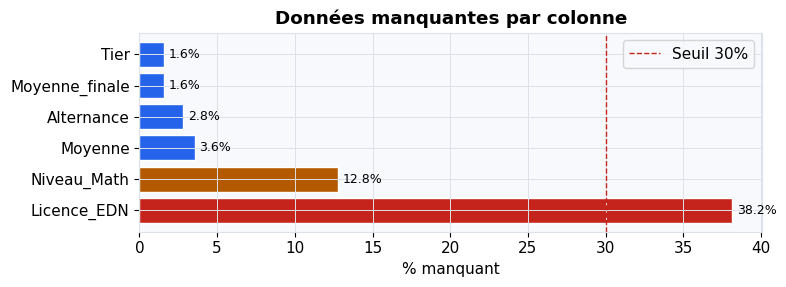


Stratégie d'imputation :
  Licence_EDN          : 38.2%  →  médiane (numérique)
  Niveau_Math          : 12.8%  →  mode (catégoriel)
  Moyenne              : 3.6%  →  médiane (numérique)
  Alternance           : 2.8%  →  médiane (numérique)
  Moyenne_finale       : 1.6%  →  médiane (numérique)
  Tier                 : 1.6%  →  mode (catégoriel)


In [10]:
miss = df_raw.isnull().mean() * 100
miss = miss[miss > 0].sort_values(ascending=False)

if len(miss) == 0:
    print("Aucune valeur manquante.")
else:
    fig, ax = plt.subplots(figsize=(8, 3))
    colors = ['#C5241C' if v > 30 else '#B35A00' if v > 10 else '#2563EB' for v in miss.values]
    ax.barh(miss.index, miss.values, color=colors, edgecolor='white')
    ax.axvline(30, color='#C5241C', linestyle='--', linewidth=1, label='Seuil 30%')
    ax.set_xlabel('% manquant')
    ax.set_title('Données manquantes par colonne', fontweight='bold')
    ax.legend()
    for i, v in enumerate(miss.values):
        ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()
    
    print("\nStratégie d'imputation :")
    for col, pct in miss.items():
        strat = 'médiane (numérique)' if df_raw[col].dtype in [np.float64, np.int64] else 'mode (catégoriel)'
        print(f"  {col:20s} : {pct:.1f}%  →  {strat}")

---
## 3. Prétraitement

In [11]:
df = df_raw.copy()

# 3.1 Supprimer les lignes sans label Tier
df = df.dropna(subset=['Tier'])
print(f"Après suppression des lignes sans Tier : {len(df)} candidats")

# 3.2 Encodage de la cible
tier_map = {'Faible': 0, 'Moyen': 1, 'Bon': 2, 'Excellent': 3}
df['y'] = df['Tier'].map(tier_map)
print(f"Distribution y : {dict(df['y'].value_counts().sort_index())}")

# 3.3 Encodage des catégorielles
# Diplome_norm : encodage ordinal manuel via LabelEncoder
le_diplome = LabelEncoder()
df['Diplome_enc'] = le_diplome.fit_transform(df['Diplome_norm'].fillna('inconnu'))

# Niveau_Math : ordinal manuel (inf_12 < sup_12)
niveau_math_map = {'inf_12': 0, 'sup_12': 1}
df['NiveauMath_enc'] = df['Niveau_Math'].map(niveau_math_map)

# 3.4 Sélection des features
FEATURES = ['Moyenne','Alternance', 'Licence_EDN', 'Diplome_enc', 'NiveauMath_enc']

X_raw = df[FEATURES].copy()
y = df['y'].values

# 3.5 Imputation
for col in X_raw.columns:
    X_raw[col] = pd.to_numeric(X_raw[col], errors='coerce')
    X_raw[col] = X_raw[col].fillna(X_raw[col].median())
X_raw = X_raw.fillna(0.0)

print(f"\nFeatures retenues ({len(FEATURES)}) : {FEATURES}")
print(f"NaN restants : {X_raw.isnull().sum().sum()}")
print(f"Shape final : {X_raw.shape}")

Après suppression des lignes sans Tier : 802 candidats
Distribution y : {0: np.int64(201), 1: np.int64(200), 2: np.int64(200), 3: np.int64(201)}

Features retenues (5) : ['Moyenne', 'Alternance', 'Licence_EDN', 'Diplome_enc', 'NiveauMath_enc']
NaN restants : 0
Shape final : (802, 5)


In [12]:
# 3.6 Normalisation min-max
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_raw.values.astype(float))

# 3.7 Split train / test stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"Train : {X_train.shape[0]} échantillons")
print(f"Test  : {X_test.shape[0]} échantillons")
print(f"Classes dans train : {np.unique(y_train, return_counts=True)}")

Train : 641 échantillons
Test  : 161 échantillons
Classes dans train : (array([0, 1, 2, 3]), array([161, 160, 160, 160]))


---
## 4. Entraînement & évaluation des modèles

In [13]:
MODELS = {
    'Random Forest'        : RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=5, random_state=SEED),
    'Gradient Boosting'    : GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=SEED),
    'Decision Tree'        : DecisionTreeClassifier(max_depth=8, min_samples_split=5, random_state=SEED),
    'Logistic Regression'  : LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', random_state=SEED),
    'SVM (RBF)'            : SVC(probability=True, kernel='rbf', C=1.0, random_state=SEED),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = {}

print(f"{'Modèle':<25} {'CV F1-macro':>12} {'CV ±':>8} {'Test F1':>10} {'Test Acc':>10}")
print("-" * 70)

for name, model in MODELS.items():
    # Cross-validation
    cv_f1  = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_macro')
    cv_acc = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    
    # Fit final + test
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    test_f1  = f1_score(y_test, y_pred, average='macro')
    test_acc = accuracy_score(y_test, y_pred)
    
    results[name] = {
        'model'   : model,
        'cv_f1'   : cv_f1.mean(),
        'cv_std'  : cv_f1.std(),
        'cv_acc'  : cv_acc.mean(),
        'test_f1' : test_f1,
        'test_acc': test_acc,
        'y_pred'  : y_pred,
    }
    print(f"{name:<25} {cv_f1.mean():>12.4f} {cv_f1.std():>8.4f} {test_f1:>10.4f} {test_acc:>10.4f}")

best_name = max(results, key=lambda k: results[k]['cv_f1'])
print(f"\nMeilleur modèle (CV F1-macro) : {best_name}  →  {results[best_name]['cv_f1']:.4f}")

Modèle                     CV F1-macro     CV ±    Test F1   Test Acc
----------------------------------------------------------------------
Random Forest                   0.9535   0.0146     0.9813     0.9814
Gradient Boosting               0.9610   0.0203     0.9937     0.9938
Decision Tree                   0.9611   0.0241     0.9875     0.9876
Logistic Regression             0.7236   0.0398     0.7599     0.7702
SVM (RBF)                       0.8235   0.0473     0.8533     0.8509

Meilleur modèle (CV F1-macro) : Decision Tree  →  0.9611


### 4.1 Comparaison visuelle des modèles

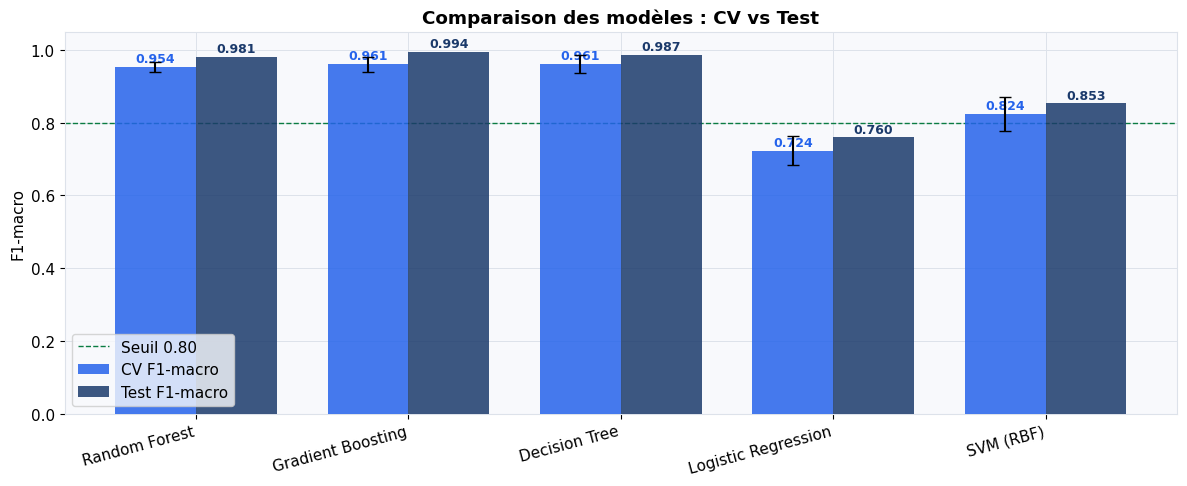

In [14]:
names   = list(results.keys())
cv_f1s  = [results[n]['cv_f1']  for n in names]
test_f1s= [results[n]['test_f1'] for n in names]
cv_stds = [results[n]['cv_std']  for n in names]

x = np.arange(len(names))
w = 0.38

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - w/2, cv_f1s,  w, label='CV F1-macro', color='#2563EB', alpha=0.85, zorder=3)
bars2 = ax.bar(x + w/2, test_f1s, w, label='Test F1-macro', color='#1B3A6B', alpha=0.85, zorder=3)
ax.errorbar(x - w/2, cv_f1s, yerr=cv_stds, fmt='none', color='black', capsize=4, linewidth=1.5, zorder=4)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('F1-macro')
ax.set_ylim(0, 1.05)
ax.axhline(0.8, color='#0A7C42', linestyle='--', linewidth=1, label='Seuil 0.80', zorder=2)
ax.set_title('Comparaison des modèles : CV vs Test', fontweight='bold')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color='#2563EB', fontweight='600')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color='#1B3A6B', fontweight='600')

plt.tight_layout()
plt.show()

### 4.2 Rapport de classification détaillé

In [15]:
print(f"=== Rapport détaillé — {best_name} (meilleur modèle) ===\n")
print(classification_report(
    y_test, results[best_name]['y_pred'],
    target_names=TIER_ORDER
))

=== Rapport détaillé — Decision Tree (meilleur modèle) ===

              precision    recall  f1-score   support

      Faible       1.00      0.95      0.97        40
       Moyen       0.95      1.00      0.98        40
         Bon       1.00      1.00      1.00        40
   Excellent       1.00      1.00      1.00        41

    accuracy                           0.99       161
   macro avg       0.99      0.99      0.99       161
weighted avg       0.99      0.99      0.99       161



### 4.3 Matrices de confusion — tous les modèles

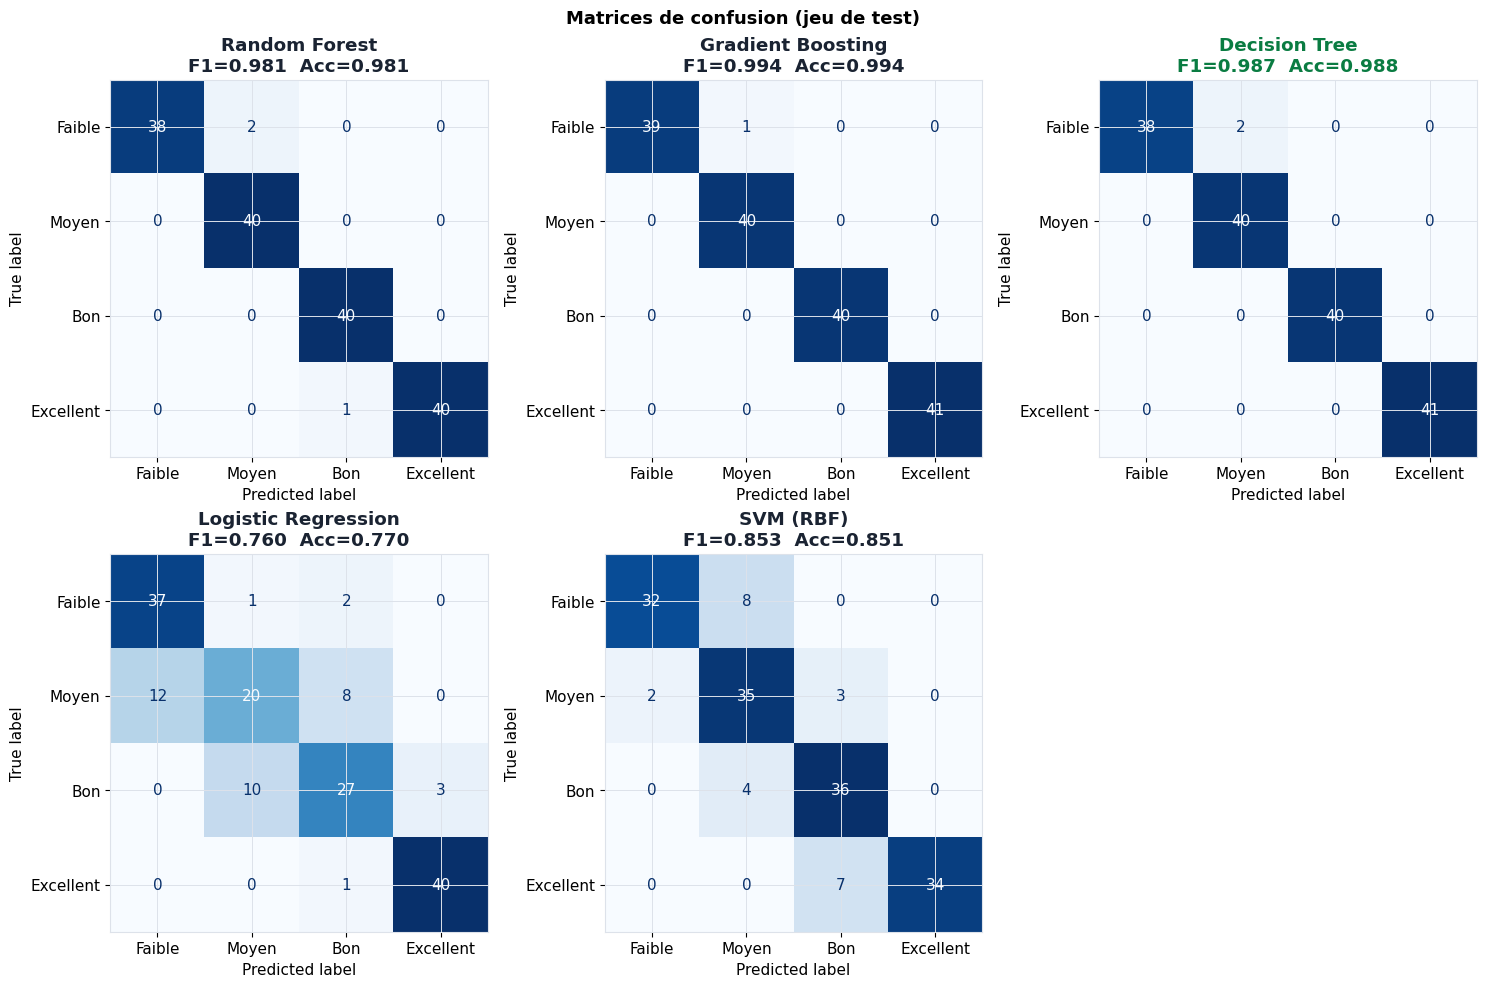

In [16]:
n_models = len(results)
ncols = 3
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=TIER_ORDER)
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    title_color = '#0A7C42' if name == best_name else '#1A2332'
    axes[i].set_title(
        f"{name}\nF1={res['test_f1']:.3f}  Acc={res['test_acc']:.3f}",
        fontweight='bold', color=title_color
    )

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Matrices de confusion (jeu de test)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Analyse de l'overfitting — Courbes d'apprentissage

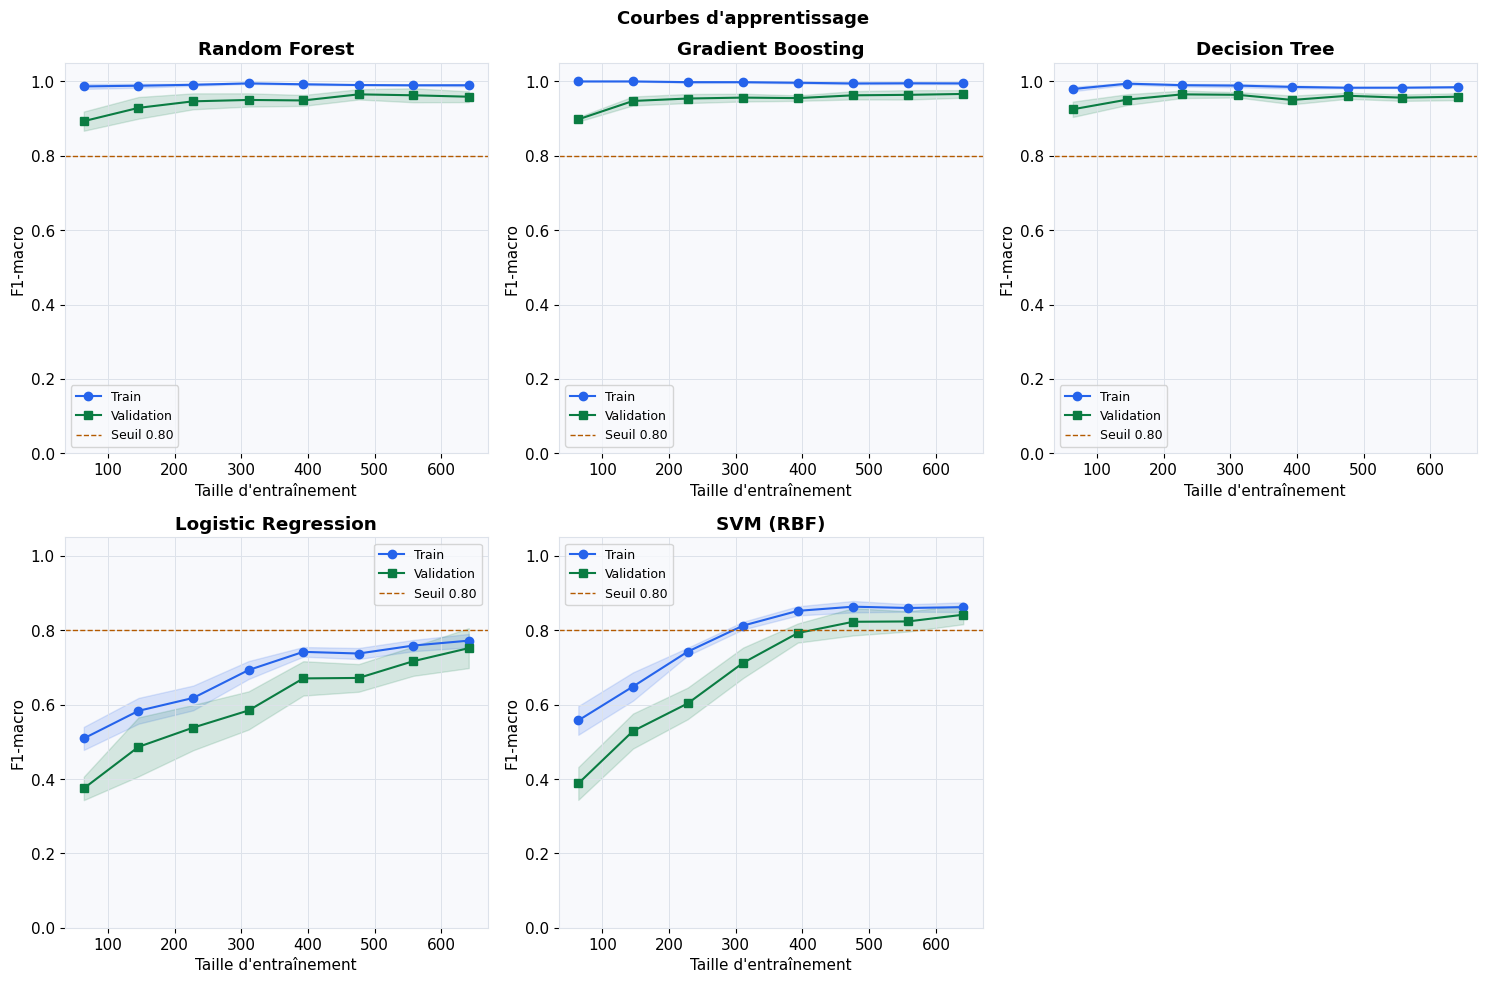

In [17]:
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    model = res['model'].__class__(**res['model'].get_params())
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_scaled, y,
        cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
        scoring='f1_macro',
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax = axes[i]
    ax.plot(train_sizes, train_mean, 'o-', color='#2563EB', label='Train')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#2563EB')
    ax.plot(train_sizes, val_mean,   's-', color='#0A7C42', label='Validation')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#0A7C42')
    ax.set_ylim(0, 1.05)
    ax.axhline(0.8, color='#B35A00', linestyle='--', linewidth=1, label='Seuil 0.80')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel("Taille d'entraînement")
    ax.set_ylabel('F1-macro')
    ax.legend(fontsize=9)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Courbes d'apprentissage", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Importance des features

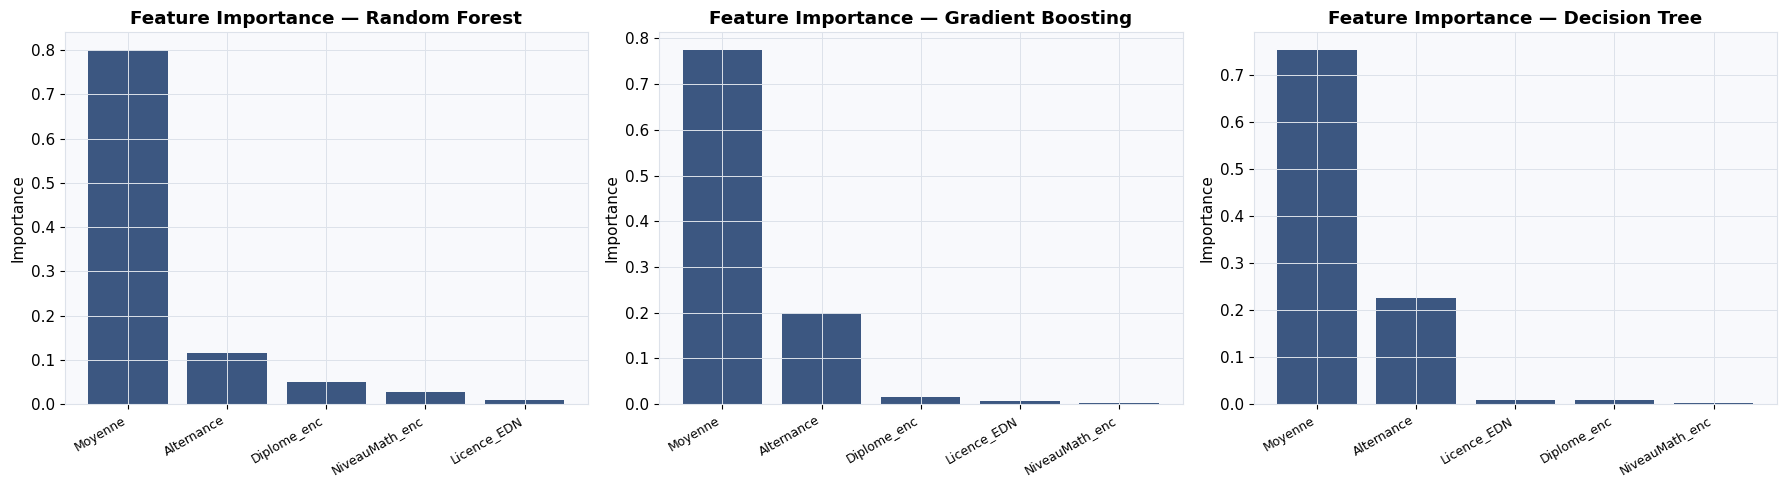

In [18]:
# Models with native feature importance
tree_models = {n: r for n, r in results.items()
               if hasattr(r['model'], 'feature_importances_')}

fig, axes = plt.subplots(1, len(tree_models), figsize=(6 * len(tree_models), 5))
if len(tree_models) == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, tree_models.items()):
    imp = res['model'].feature_importances_
    idx = np.argsort(imp)[::-1]
    ax.bar(np.arange(len(FEATURES)), imp[idx], color='#1B3A6B', alpha=0.85)
    ax.set_xticks(np.arange(len(FEATURES)))
    ax.set_xticklabels([FEATURES[i] for i in idx], rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Importance')
    ax.set_title(f'Feature Importance — {name}', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 7. Analyse SHAP

In [19]:
try:
    import shap
    SHAP_AVAILABLE = True
    print(f"SHAP version : {shap.__version__}")
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP non installé. Installez-le avec : pip install shap")
    print("Cette section sera ignorée.")

SHAP version : 0.51.0


In [ ]:
if SHAP_AVAILABLE:
    best_model = results[best_name]["model"]

    if hasattr(best_model, "feature_importances_"):
        explainer = shap.TreeExplainer(best_model)
        shap_values = explainer.shap_values(X_test)

        # Ancienne API : list[classe] | Nouvelle API >= 0.42 : (samples, features, classes)
        if isinstance(shap_values, list):
            sv_excellent = np.array(shap_values[3])
        elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
            sv_excellent = shap_values[:, :, 3]
        else:
            sv_excellent = np.array(shap_values)

        print(f"SHAP calcules pour {X_test.shape[0]} candidats du jeu de test.")
        print(f"Shape sv_excellent : {sv_excellent.shape}")
    else:
        bg = shap.sample(X_train, 50)
        explainer = shap.PermutationExplainer(best_model.predict_proba, bg)
        shap_result = explainer(X_test[:50])
        sv_excellent = shap_result.values[:, :, 3]
        print("PermutationExplainer utilise (fallback).")


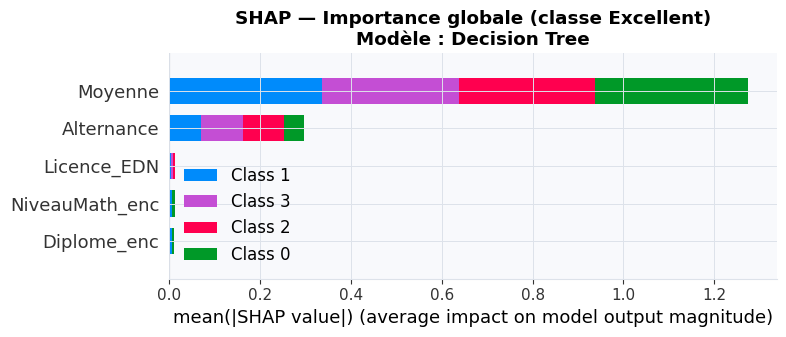

In [21]:
if SHAP_AVAILABLE and 'sv_excellent' in dir():
    shap.summary_plot(
        sv_excellent, X_test,
        feature_names=FEATURES,
        plot_type='bar',
        show=False
    )
    plt.title(f'SHAP — Importance globale (classe Excellent)\nModèle : {best_name}', fontweight='bold')
    plt.tight_layout()
    plt.show()

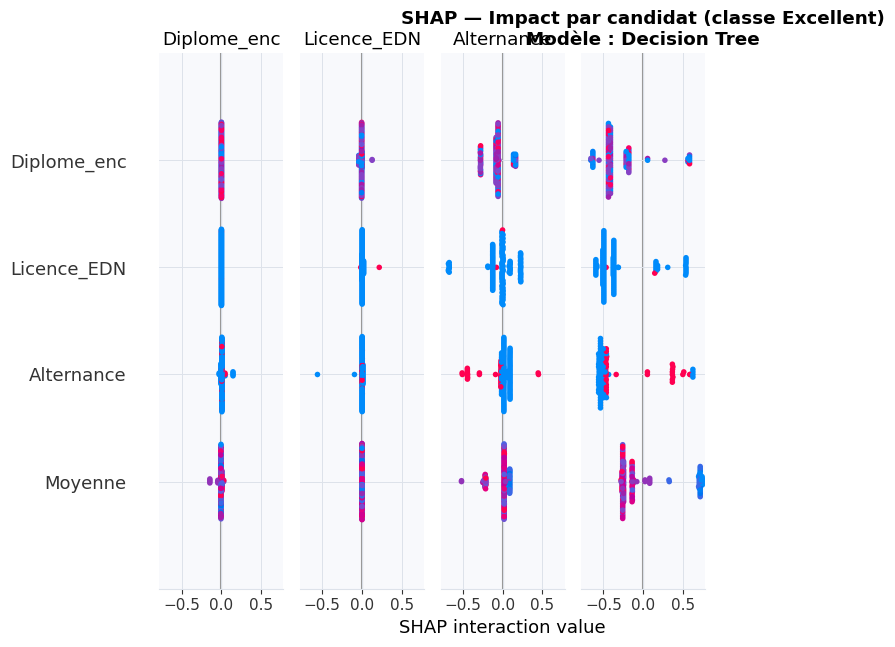

In [22]:
if SHAP_AVAILABLE and 'sv_excellent' in dir():
    shap.summary_plot(
        sv_excellent, X_test,
        feature_names=FEATURES,
        plot_type='dot',
        show=False
    )
    plt.title(f'SHAP — Impact par candidat (classe Excellent)\nModèle : {best_name}', fontweight='bold')
    plt.tight_layout()
    plt.show()

### 7.3 Explication d'un candidat individuel

Candidat selectionne (index 0) :
  Tier predit  : Excellent
  Tier reel    : Excellent
  P(Excellent) = 1.000


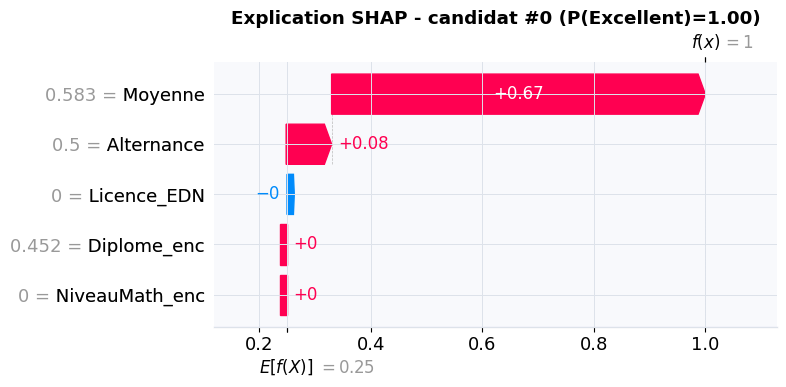

In [24]:
if SHAP_AVAILABLE and "sv_excellent" in dir():
    proba_exc = results[best_name]["model"].predict_proba(X_test)
    best_candidate_idx = np.argmax(proba_exc[:, -1])

    pred_tier = TIER_ORDER[results[best_name]["y_pred"][best_candidate_idx]]
    true_tier = TIER_ORDER[y_test[best_candidate_idx]]
    print(f"Candidat selectionne (index {best_candidate_idx}) :")
    print(f"  Tier predit  : {pred_tier}")
    print(f"  Tier reel    : {true_tier}")
    print(f"  P(Excellent) = {proba_exc[best_candidate_idx, -1]:.3f}")

    # expected_value : scalaire ou tableau multiclasse -> extraire indice 3
    arr_ev = np.atleast_1d(explainer.expected_value)
    exp_val_scalar = float(arr_ev[3]) if len(arr_ev) > 3 else float(arr_ev[-1])

    # sv_excellent[idx] doit etre 1D (n_features,)
    sv_row = np.array(sv_excellent[best_candidate_idx])
    if sv_row.ndim > 1:
        sv_row = sv_row[:, 3]

    shap_exp = shap.Explanation(
        values=sv_row,
        base_values=exp_val_scalar,
        data=X_test[best_candidate_idx],
        feature_names=FEATURES
    )
    shap.waterfall_plot(shap_exp, show=False)
    plt.title(
        f"Explication SHAP - candidat #{best_candidate_idx} "
        f"(P(Excellent)={proba_exc[best_candidate_idx, -1]:.2f})",
        fontweight="bold"
    )
    plt.tight_layout()
    plt.show()


---
## 8. Synthèse finale

In [25]:
print("=" * 65)
print("SYNTHÈSE — Validation du module IA")
print("=" * 65)
print(f"\nJeu de données    : {len(df)} candidats, {len(FEATURES)} features")
print(f"Distribution tiers: {dict(pd.Series(y).value_counts().sort_index().rename(lambda i: TIER_ORDER[i]))}")
print()

print(f"{'Modèle':<25} {'CV F1':>8} {'CV ±':>8} {'Test F1':>9} {'Test Acc':>10}  Verdict")
print("-" * 80)

for name, res in sorted(results.items(), key=lambda x: x[1]['cv_f1'], reverse=True):
    marker = ' <-- MEILLEUR' if name == best_name else ''
    verdict = 'Excellent' if res['cv_f1'] >= 0.85 else 'Bon' if res['cv_f1'] >= 0.70 else 'Moyen' if res['cv_f1'] >= 0.55 else 'Faible'
    print(f"{name:<25} {res['cv_f1']:>8.4f} {res['cv_std']:>8.4f} {res['test_f1']:>9.4f} {res['test_acc']:>10.4f}  {verdict}{marker}")

print()
gap = results[best_name]['cv_f1'] - results[best_name]['test_f1']
overfit_status = 'Pas d\'overfitting détecté' if abs(gap) < 0.05 else f'Écart CV/Test = {gap:.3f} (à surveiller)'
print(f"Overfitting check : {overfit_status}")
print()
print("Recommandation :")
if results[best_name]['cv_f1'] >= 0.70:
    print(f"  ✓  Le module ML est PERTINENT pour l'application.")
    print(f"  ✓  Modèle recommandé : {best_name}  (F1-macro CV = {results[best_name]['cv_f1']:.4f})")
    print(f"  →  Prêt pour l'intégration dans le pipeline AHP-TOPSIS-ML.")
else:
    print(f"  ⚠  Performance insuffisante (F1 < 0.70). Revoir le prétraitement ou les features.")
print("=" * 65)

SYNTHÈSE — Validation du module IA

Jeu de données    : 802 candidats, 5 features
Distribution tiers: {'Faible': np.int64(201), 'Moyen': np.int64(200), 'Bon': np.int64(200), 'Excellent': np.int64(201)}

Modèle                       CV F1     CV ±   Test F1   Test Acc  Verdict
--------------------------------------------------------------------------------
Decision Tree               0.9611   0.0241    0.9875     0.9876  Excellent <-- MEILLEUR
Gradient Boosting           0.9610   0.0203    0.9937     0.9938  Excellent
Random Forest               0.9535   0.0146    0.9813     0.9814  Excellent
SVM (RBF)                   0.8235   0.0473    0.8533     0.8509  Bon
Logistic Regression         0.7236   0.0398    0.7599     0.7702  Bon

Overfitting check : Pas d'overfitting détecté

Recommandation :
  ✓  Le module ML est PERTINENT pour l'application.
  ✓  Modèle recommandé : Decision Tree  (F1-macro CV = 0.9611)
  →  Prêt pour l'intégration dans le pipeline AHP-TOPSIS-ML.
